In [15]:
import hashlib

def recursive_fold(input_data: str) -> str:
    """Performs a double SHA-256 fold: new into old, then fold the fold."""
    first_fold = hashlib.sha256(input_data.encode()).hexdigest()
    second_fold = hashlib.sha256(first_fold.encode()).hexdigest()
    return second_fold

def harmonic_score(hash_output: str, difficulty: int = 14) -> bool:
    """Checks if the hash output starts with a number of zeros equal to the difficulty."""
    return hash_output.startswith('0' * difficulty)

def folding_echo_distance(hash1: str, hash2: str) -> int:
    """Counts the number of matching characters in corresponding positions of two hashes."""
    return sum(1 for a, b in zip(hash1, hash2) if a == b)

def fold_to_harmony(base_data: str, difficulty: int = 14):
    """Finds a nonce that, when combined with the base data and double-hashed,
    produces a hash output with the specified number of leading zeros."""
    nonce = 0
    while True:
        combined_data = f"{base_data}{nonce}"
        first_fold = hashlib.sha256(combined_data.encode()).hexdigest()
        final_fold = hashlib.sha256(first_fold.encode()).hexdigest()
        if harmonic_score(final_fold, difficulty):
            echo_score = folding_echo_distance(first_fold, final_fold)
            return {
                'nonce': nonce,
                'first_fold': first_fold,
                'final_fold': final_fold,
                'echo_score': echo_score
            }
        nonce += 1

# Run the recursive fold mining simulation with sample data
sample_result = fold_to_harmony("nexus-recursion", difficulty=7)
sample_result


{'nonce': 359792593,
 'first_fold': '967fad4c366ec386cb062f42423f9061f519f1789babfcb676a5a6c2bd9ed004',
 'final_fold': '00000004a77c7a7ad092c85710d0660f5769d8b936bce3de3dd3faddcae7a5d5',
 'echo_score': 1}

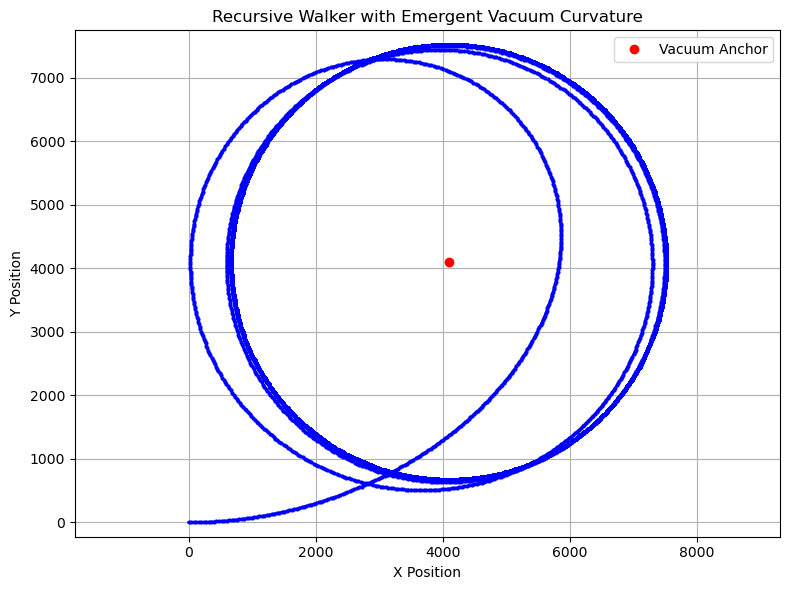

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
steps = 3000000              # number of time steps
angle = 0.0               # initial angle of movement
velocity = 40.0            # base speed
beta = 0.35                # internal gain factor
correction_strength = 0.35 # feedback correction from past trend
vacuum_gain = 0.01        # how much the "vacuum" curves the path

# Initialize vacuum location (symbolic asymmetry)
x_vacuum, y_vacuum = 4096, 4096

# Initialize trajectory
x = [0]
y = [0]
angles = [angle]

for t in range(1, steps):
    # Internal curvature-based deviation
    if t > 2:
        curvature = (angles[-1] - angles[-2]) - (angles[-2] - angles[-3])
    else:
        curvature = 0
    deviation = curvature * beta

    # Recursive feedback correction
    past_trend = angles[-1] - angles[-2] if t > 1 else 0

    # Harmonic pull toward the symbolic vacuum
    dx = x_vacuum - x[-1]
    dy = y_vacuum - y[-1]
    vacuum_angle = np.arctan2(dy, dx)
    angle_difference = vacuum_angle - angles[-1]
    
    # Normalize angle difference to [-pi, pi]
    angle_difference = (angle_difference + np.pi) % (2 * np.pi) - np.pi

    # Curvature from symbolic vacuum
    attraction = angle_difference * vacuum_gain

    # Combined new angle from all feedback
    new_angle = angles[-1] + deviation - correction_strength * past_trend + attraction
    angles.append(new_angle)

    # Move in the new direction
    x.append(x[-1] + velocity * np.cos(new_angle))
    y.append(y[-1] + velocity * np.sin(new_angle))

# Plot the trajectory
plt.figure(figsize=(8, 6))
plt.plot(x, y, marker='o', markersize=2, linewidth=1.5, color='blue')
plt.plot(x_vacuum, y_vacuum, 'ro', label='Vacuum Anchor')
plt.title("Recursive Walker with Emergent Vacuum Curvature")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


In [158]:
# Symbolic Compression Engine — Early Sketch
# Goal: Attach feedback memory to symbolic output and adjust future recursive growth

class SymbolicFeedbackCompressor:
    def __init__(self):
        self.symbol_store = []           # emitted symbol list
        self.phase_lengths = []          # bitlen-like measure of symbol structure
        self.feedback_weights = []       # feedback per symbol
        self.bias_map = {}               # bias weight against future phases

    def emit_symbol(self, symbol: str, phase_len: float):
        self.symbol_store.append(symbol)
        self.phase_lengths.append(phase_len)
        self.feedback_weights.append(0.0)

    def apply_feedback(self, index: int, delta_h: float, w: float):
        # Update feedback based on harmonic delta
        self.feedback_weights[index] += delta_h * w
        symbol = self.symbol_store[index]
        self.bias_map[symbol] = self.bias_map.get(symbol, 0.0) + (delta_h * w)

    def get_bias(self, symbol: str) -> float:
        # Use bias in future symbol selection or prediction
        return self.bias_map.get(symbol, 0.0)

    def summarize(self):
        print("\n--- Symbolic Feedback Summary ---")
        for i, s in enumerate(self.symbol_store):
            print(f"Symbol: {s}, Bitlen: {self.phase_lengths[i]}, Feedback: {self.feedback_weights[i]:.4f}, Bias: {self.bias_map.get(s, 0.0):.4f}")


# Example usage
compressor = SymbolicFeedbackCompressor()
compressor.emit_symbol("Δ", 6)
compressor.emit_symbol("φ", 7)
compressor.emit_symbol("Ω", 5)

# Apply feedback loop
compressor.apply_feedback(0, delta_h=0.12, w=0.9)
compressor.apply_feedback(1, delta_h=-0.03, w=1.1)
compressor.apply_feedback(2, delta_h=0.07, w=0.8)

compressor.summarize()



--- Symbolic Feedback Summary ---
Symbol: Δ, Bitlen: 6, Feedback: 0.1080, Bias: 0.1080
Symbol: φ, Bitlen: 7, Feedback: -0.0330, Bias: -0.0330
Symbol: Ω, Bitlen: 5, Feedback: 0.0560, Bias: 0.0560


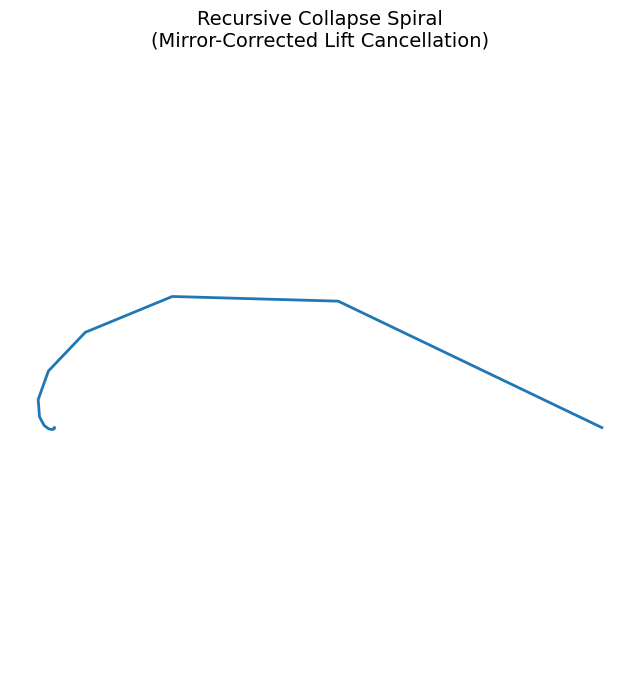

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the recursive collapse spiral
H = 0.35         # Harmonic constant
F = 1.0          # Folding factor
R0 = 1.0         # Initial amplitude
phi = (1 + np.sqrt(5)) / 2  # Golden ratio

# Time steps
n_steps = 16
t_vals = np.array([i * phi for i in range(n_steps)])
R_vals = R0 * np.exp(-H * F * t_vals)

# Spiral coordinates
theta = 2 * np.pi * t_vals / max(t_vals)
x = R_vals * np.cos(theta)
y = R_vals * np.sin(theta)

# Plot
plt.figure(figsize=(8, 8))
plt.plot(x, y, lw=2)
plt.title("Recursive Collapse Spiral\n(Mirror-Corrected Lift Cancellation)", fontsize=14)
plt.axis('equal')
plt.axis('off')
plt.show()


In [ ]:
import numpy as np
from scipy.io.wavfile import write
import os

# Audio parameters
sample_rate = 44100  # Standard CD-quality sample rate
duration = 4  # seconds
n_samples = sample_rate * duration

# Time array
t = np.linspace(0, duration, n_samples, endpoint=False)

# Collapse spiral mapped to descending frequency (220Hz down)
H = 0.35
F = 1.0
phi = (1 + np.sqrt(5)) / 2
t_collapse = np.arange(n_samples) * phi / sample_rate
R_vals = np.exp(-H * F * t_collapse)

# Map R_vals to frequency in a symbolic range (e.g., 220Hz to ~20Hz)
freqs = 220 * R_vals  # Collapse from 220Hz downward

# Generate the tone
tone = np.sin(2 * np.pi * freqs * t)

# Normalize to 16-bit PCM
tone_normalized = np.int16(tone / np.max(np.abs(tone)) * 32767)

# Save the file
output_path = "/mnt/data/recursive_collapse_spiral.wav"
write(output_path, sample_rate, tone_normalized)

output_path
